import important libraries

In [2]:
import pandas as pd

# load data from a CSV file
data = pd.read_csv('D:\salary-prediction-ML\data\salary_dataset.csv')
data.head()

,YearsExperience,Education,JobRole,Location,SkillsScore(1-5),CompanySize,Salary(LPA)
0,6,Bachelors,Data Scientist,Bangalore,2,Mid,33.86
1,19,Bachelors,ML Engineer,Hyderabad,4,Mid,66.48
2,14,PhD,BI Analyst,Delhi,1,Enterprise,47.39
3,10,Bachelors,BI Analyst,Bangalore,3,Enterprise,43.24
4,7,Bachelors,Data Scientist,Mumbai,4,Enterprise,45.90


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YearsExperience   3000 non-null   int64  
 1   Education         3000 non-null   object 
 2   JobRole           3000 non-null   object 
 3   Location          3000 non-null   object 
 4   SkillsScore(1-5)  3000 non-null   int64  
 5   CompanySize       3000 non-null   object 
 6   Salary(LPA)       3000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 164.2+ KB


In [4]:
data.describe()

,YearsExperience,SkillsScore(1-5),Salary(LPA)
count,3000.000000,3000.000000,3000.00000
mean,9.915333,3.016000,44.55748
std,6.147419,1.407742,16.67430
min,0.000000,1.000000,4.62000
25%,4.000000,2.000000,31.50750
50%,10.000000,3.000000,44.68000
75%,15.000000,4.000000,57.78000
max,20.000000,5.000000,86.40000


In [5]:
data.shape

(3000, 7)

In [6]:
# check for missing values
data.isnull().sum()

YearsExperience     0
Education           0
JobRole             0
Location            0
SkillsScore(1-5)    0
CompanySize         0
Salary(LPA)         0
dtype: int64

In [9]:
print("\nUnique Education:", data["Education"].unique())
print("\nUnique Job Roles:", data["JobRole"].unique())
print("\nUnique Locations:", data["Location"].unique())
print("\nUnique Company Sizes:", data["CompanySize"].unique())


Unique Education: ['Bachelors' 'PhD' 'Masters']

Unique Job Roles: ['Data Scientist' 'ML Engineer' 'BI Analyst' 'Data Analyst']

Unique Locations: ['Bangalore' 'Hyderabad' 'Delhi' 'Mumbai' 'Pune']

Unique Company Sizes: ['Mid' 'Enterprise' 'Startup']


In [10]:
# VISUAL ANALYSIS
import matplotlib.pyplot as plt
import seaborn as sns

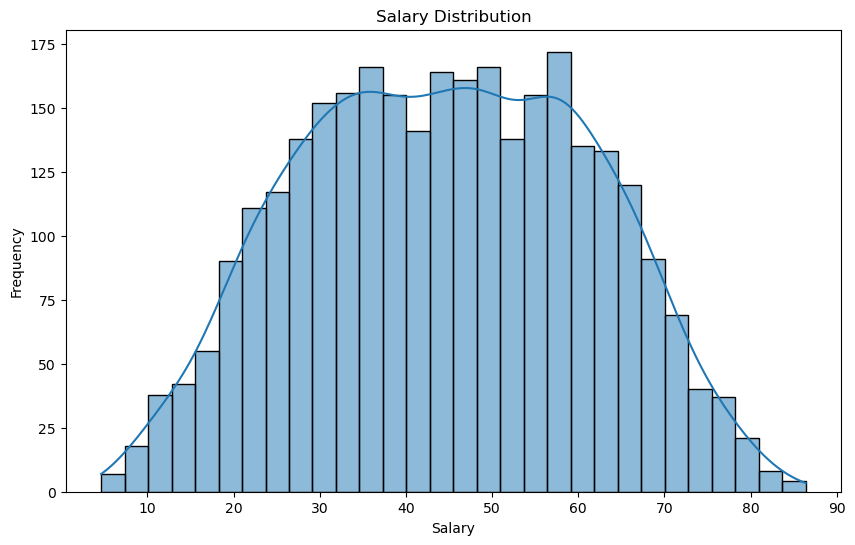

In [13]:
# histogram of Salary
plt.figure(figsize=(10, 6))
sns.histplot(data['Salary(LPA)'], bins=30, kde=True) 
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

In [23]:
# PREPROCESSING START

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [15]:
data = pd.read_csv('D:\salary-prediction-ML\data\salary_dataset.csv')
data.head()

,YearsExperience,Education,JobRole,Location,SkillsScore(1-5),CompanySize,Salary(LPA)
0,6,Bachelors,Data Scientist,Bangalore,2,Mid,33.86
1,19,Bachelors,ML Engineer,Hyderabad,4,Mid,66.48
2,14,PhD,BI Analyst,Delhi,1,Enterprise,47.39
3,10,Bachelors,BI Analyst,Bangalore,3,Enterprise,43.24
4,7,Bachelors,Data Scientist,Mumbai,4,Enterprise,45.90


In [16]:
# Encode categorical columns
le_edu = LabelEncoder()
le_role = LabelEncoder()
le_loc = LabelEncoder()
le_size = LabelEncoder()


In [17]:
data['Education'] = le_edu.fit_transform(data['Education'])
data['JobRole'] = le_role.fit_transform(data['JobRole'])
data['Location'] = le_loc.fit_transform(data['Location'])
data['CompanySize'] = le_size.fit_transform(data['CompanySize'])

In [18]:
X = data.drop("Salary(LPA)", axis=1)
y = data["Salary(LPA)"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
X_train.shape

(2400, 6)

In [21]:
X_test.shape

(600, 6)

In [24]:
#-----models------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
}

In [25]:
best_score = 0
best_model = None

In [26]:
for name,model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name} R^2 Score: {score}")
    if score > best_score:
        best_score = score
        best_model = model

Linear Regression R^2 Score: 0.964077484709638
Decision Tree R^2 Score: 0.9044362885097987
Random Forest R^2 Score: 0.9313405203148774


In [27]:
print("\nBest Model Selected:", best_model)


Best Model Selected: LinearRegression()


In [29]:
print(X.columns)

Index(['YearsExperience', 'Education', 'JobRole', 'Location',
       'SkillsScore(1-5)', 'CompanySize'],
      dtype='object')
